First rows of the dataset:
   Campaign_ID  Platform Campaign_Type Country   Device  Impressions  Clicks  \
0   CAMP-0001   YouTube         Email  Brazil   Tablet        15924     828   
1   CAMP-0002  LinkedIn         Email  Mexico   Tablet        77162    1022   
2   CAMP-0003    TikTok         Email      UK   Mobile         1869    2860   
3   CAMP-0004  LinkedIn           SEO   Spain   Mobile        98088    2173   
4   CAMP-0005  LinkedIn           SEO   Spain  Desktop         2014     648   

   Conversions   Revenue     Spend        Date     CTR   CPC  ROAS  
0          151  19083.34   7200.34  2024-01-01  0.0520  8.70  2.65  
1          585   4277.37   2750.52  2024-01-02  0.0132  2.69  1.56  
2          273  15799.65   7310.18  2024-01-03  1.5302  2.56  2.16  
3          553  15513.98  10577.42  2024-01-04  0.0222  4.87  1.47  
4          495   4432.81    495.37  2024-01-05  0.3217  0.76  8.95  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to

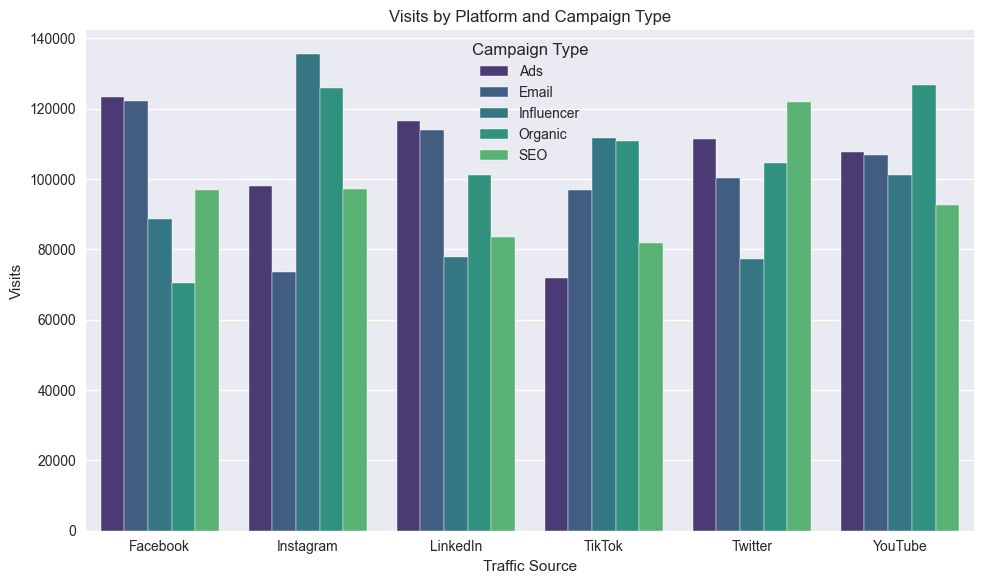

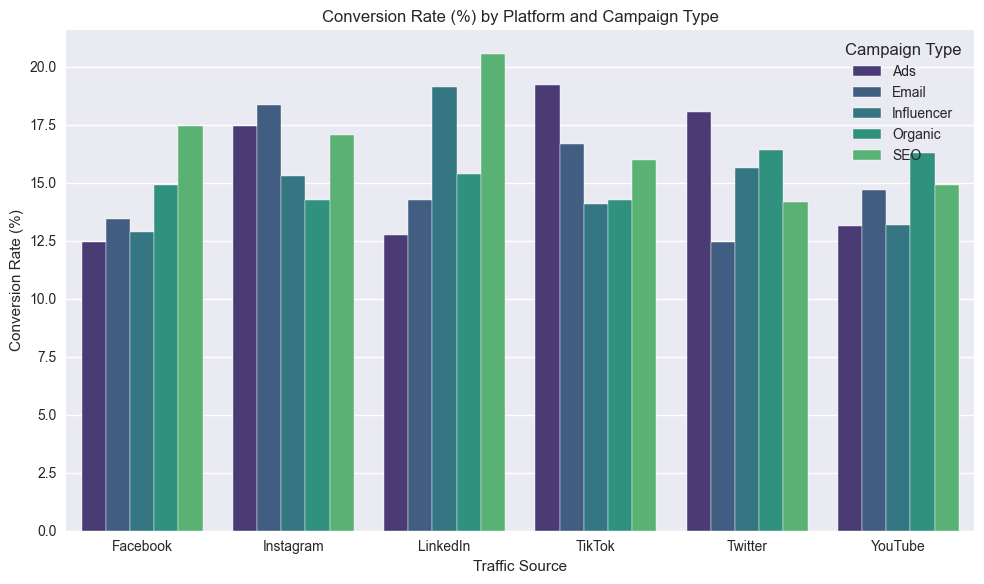

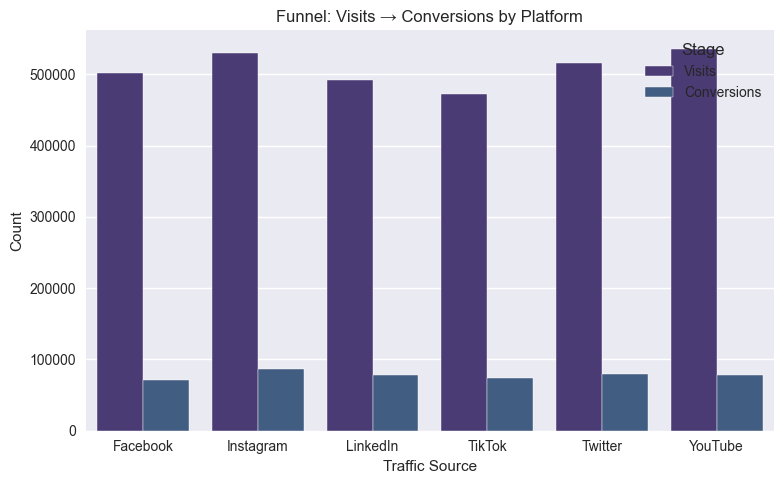


📢 Insights:
- The channel with the **highest conversion rate** is LinkedIn (SEO) with 20.55%.
- The **most profitable channel** (highest ROAS) is LinkedIn (SEO) with a ROAS of 1.64.


In [10]:
# =========================================
# 📊 Digital Marketing Campaign Analysis
# =========================================

# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
plt.style.use('seaborn-v0_8')
sns.set_palette("viridis")

# 2. Load dataset
# 👉 Replace with the actual file name and path
df = pd.read_csv("digital_marketing_campaigns.csv")  

# Preview
print("First rows of the dataset:\n", df.head())

# 3. Basic info
print("\nDataset info:")
print(df.info())

# Check missing values
print("\nMissing values:\n", df.isnull().sum())

# Convert date column
df['Date'] = pd.to_datetime(df['Date'])

# =========================================
# 🔎 Metrics by Traffic Source & Campaign Type
# =========================================

summary = df.groupby(['Platform', 'Campaign_Type']).agg(
    Visits=('Clicks', 'sum'),                # Use clicks as effective visits
    Conversions=('Conversions', 'sum'),
    Revenue=('Revenue', 'sum'),
    Spend=('Spend', 'sum')
).reset_index()

# Compute KPIs
summary['Conversion_Rate'] = (summary['Conversions'] / summary['Visits']) * 100
summary['ROAS'] = summary['Revenue'] / summary['Spend']

# Round for readability
summary['Conversion_Rate'] = summary['Conversion_Rate'].round(2)
summary['ROAS'] = summary['ROAS'].round(2)

print("\nSummary by Platform and Campaign Type:\n")
print(summary)

# =========================================
# 📊 Visualizations
# =========================================

# 1. Visits by Traffic Source
plt.figure(figsize=(10,6))
sns.barplot(data=summary, x='Platform', y='Visits', hue='Campaign_Type')
plt.title("Visits by Platform and Campaign Type")
plt.xlabel("Traffic Source")
plt.ylabel("Visits")
plt.legend(title='Campaign Type')
plt.tight_layout()
plt.show()

# 2. Conversion Rate
plt.figure(figsize=(10,6))
sns.barplot(data=summary, x='Platform', y='Conversion_Rate', hue='Campaign_Type')
plt.title("Conversion Rate (%) by Platform and Campaign Type")
plt.xlabel("Traffic Source")
plt.ylabel("Conversion Rate (%)")
plt.legend(title='Campaign Type')
plt.tight_layout()
plt.show()

# 3. Funnel (Visits → Conversions)
funnel = summary.groupby('Platform')[['Visits','Conversions']].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    data=funnel.melt(id_vars='Platform', var_name='Stage', value_name='Count'),
    x='Platform', y='Count', hue='Stage'
)
plt.title("Funnel: Visits → Conversions by Platform")
plt.xlabel("Traffic Source")
plt.ylabel("Count")
plt.legend(title='Stage')
plt.tight_layout()
plt.show()

# =========================================
# 📈 Auto-Insights
# =========================================

best_conv = summary.sort_values(by='Conversion_Rate', ascending=False).iloc[0]
best_roas = summary.sort_values(by='ROAS', ascending=False).iloc[0]

print("\n📢 Insights:")
print(f"- The channel with the **highest conversion rate** is "
      f"{best_conv['Platform']} ({best_conv['Campaign_Type']}) "
      f"with {best_conv['Conversion_Rate']}%.")
print(f"- The **most profitable channel** (highest ROAS) is "
      f"{best_roas['Platform']} ({best_roas['Campaign_Type']}) "
      f"with a ROAS of {best_roas['ROAS']}.")
